# 20. External Scent Knowledge Validation

Stage 19에서 `RELATED` 또는 `UNRESOLVED`로 남은 고빈도 Note 30개를 IFRA, Givaudan,
IFF, dsm-firmenich, PubChem의 공식 자료로 재검증한다. 검색 결과 문구는 근거로 쓰지 않고,
실제로 열어 확인한 공식 페이지의 짧은 요약만 저장한다. Strict Coverage에는
`HIGH + SAME_CONCEPT`만 추가하며 FAMILY/RELATED는 보수적으로 분리한다.


In [1]:
from pathlib import Path
import collections
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown


def markdown_table(frame):
    table = frame.copy()
    for column in table.columns:
        table[column] = table[column].map(
            lambda value: str(value).replace("|", "\\|").replace("\n", " ")
        )
    header = "| " + " | ".join(map(str, table.columns)) + " |"
    rule = "| " + " | ".join(["---"] * len(table.columns)) + " |"
    rows = ["| " + " | ".join(row) + " |" for row in table.astype(str).to_numpy().tolist()]
    return "\n".join([header, rule, *rows])


ROOT = Path.cwd()
DATA = ROOT / "data"
KNOWLEDGE = DATA / "scent_knowledge"
OUTPUT = ROOT / "analysis_outputs"
IFRA_PROCESSED = DATA / "external" / "ifra" / "processed"
OUTPUT.mkdir(parents=True, exist_ok=True)
KNOWLEDGE.mkdir(parents=True, exist_ok=True)

PATHS = {
    "perfumes_csv": ROOT / "perfumes.csv",
    "perfumes_jsonl": ROOT / "perfumes.jsonl",
    "schema": ROOT / "SCHEMA.md",
    "ifra_pdf": DATA / "external" / "ifra" / "raw" / "ifra-fragrance-ingredient-glossary-april-2020.pdf",
    "ifra_ingredients": IFRA_PROCESSED / "ifra_ingredients_2020.csv",
    "ifra_definitions": IFRA_PROCESSED / "ifra_primary_descriptor_definitions_2020.csv",
    "dictionary_v01": KNOWLEDGE / "scent_term_dictionary_v0.1.csv",
    "dictionary_v02": KNOWLEDGE / "scent_term_dictionary_v0.2.csv",
    "evidence_v01": KNOWLEDGE / "scent_term_evidence_v0.1.csv",
    "evidence_v02": KNOWLEDGE / "scent_term_evidence_v0.2.csv",
    "stage17_matching": OUTPUT / "17_note_ifra_matching.csv",
    "stage17_unmatched": OUTPUT / "17_top_unmatched_notes.csv",
    "stage18_decisions": OUTPUT / "18_scent_term_validation_decisions.csv",
    "stage19_targets": OUTPUT / "19_validation_target_notes.csv",
    "stage19_decisions": OUTPUT / "19_scent_term_expansion_decisions.csv",
    "stage19_unresolved": OUTPUT / "19_high_frequency_unresolved_notes.csv",
    "stage19_contribution": OUTPUT / "19_mapping_coverage_contribution.csv",
    "stage19_topn": OUTPUT / "19_top_note_coverage_comparison.csv",
    "stage19_summary": OUTPUT / "19_scent_term_dictionary_expansion_summary.md",
}

missing = [str(path) for path in PATHS.values() if not path.exists()]
assert not missing, f"Missing required inputs: {missing}"

stage17 = pd.read_csv(PATHS["stage17_matching"], keep_default_na=False)
stage19_unresolved = pd.read_csv(PATHS["stage19_unresolved"], keep_default_na=False)
dictionary_v01 = pd.read_csv(PATHS["dictionary_v01"], keep_default_na=False)
dictionary_v02 = pd.read_csv(PATHS["dictionary_v02"], keep_default_na=False)
evidence_v02 = pd.read_csv(PATHS["evidence_v02"], keep_default_na=False)
ifra = pd.read_csv(PATHS["ifra_ingredients"], keep_default_na=False)

required = {
    "stage17": {"note", "perfume_count", "occurrence_count", "final_auto_status"},
    "stage19_unresolved": {
        "note", "perfume_count", "occurrence_count", "relation_type", "confidence", "decision_reason"
    },
    "dictionary_v02": {
        "term", "term_type", "canonical_term", "relation_type", "parent_term",
        "iframapped_term", "decision", "confidence", "evidence_count", "notes", "version"
    },
    "evidence_v02": {
        "term", "candidate_term", "source_org", "source_title", "source_url", "source_type",
        "evidence_type", "evidence_summary", "supports_relation", "retrieved_at"
    },
}
frames = {
    "stage17": stage17,
    "stage19_unresolved": stage19_unresolved,
    "dictionary_v02": dictionary_v02,
    "evidence_v02": evidence_v02,
}
for name, columns in required.items():
    absent = columns - set(frames[name].columns)
    assert not absent, f"{name} schema mismatch: {sorted(absent)}"

print(f"Loaded {len(stage17):,} note rows, {len(dictionary_v02):,} dictionary rows, "
      f"and {len(evidence_v02):,} evidence rows.")



Loaded 2,523 note rows, 167 dictionary rows, and 181 evidence rows.


## 1. 검증 대상

Stage 19 결과 중 `RELATED` 또는 `UNRESOLVED`만 남기고 occurrence 내림차순 상위 30개를
선택한다. 대표 10개는 별도 하드코딩 없이 실제 정렬 결과에 포함되는지 검증한다.


In [2]:
eligible = stage19_unresolved.loc[
    stage19_unresolved["relation_type"].isin(["RELATED", "UNRESOLVED"])
].copy()
targets = eligible.sort_values(
    ["occurrence_count", "perfume_count", "note"], ascending=[False, False, True]
).head(30).reset_index(drop=True)
targets.insert(0, "rank", np.arange(1, len(targets) + 1))
targets = targets.rename(columns={
    "relation_type": "stage19_relation",
    "confidence": "stage19_confidence",
    "decision_reason": "stage19_reason",
})
target_cols = [
    "rank", "note", "perfume_count", "occurrence_count",
    "stage19_relation", "stage19_confidence", "stage19_reason",
]
targets[target_cols].to_csv(
    OUTPUT / "20_external_validation_targets.csv", index=False, encoding="utf-8-sig"
)

representative = {
    "Mandarin Orange", "Orange Blossom", "Leather", "Pink Pepper", "Lily-of-the-Valley",
    "Freesia", "Black Pepper", "Mint", "Moss", "Woodsy Notes",
}
assert len(targets) == 30
assert representative.issubset(set(targets["note"]))
display(targets[target_cols])



,rank,note,perfume_count,occurrence_count,stage19_relation,stage19_confidence,stage19_reason
0,1,Mandarin Orange,11646,11652,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."
1,2,Orange Blossom,11479,11545,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."
2,3,Leather,10626,10754,RELATED,MEDIUM,RELATED_DESCRIPTOR_ONLY: IFRA contains a close...
3,4,Pink Pepper,10387,10395,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."
4,5,Lily-of-the-Valley,7339,7366,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."
5,6,Freesia,5683,5696,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."
6,7,Black Pepper,4795,4807,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."
7,8,Mint,4605,4627,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."
8,9,Moss,4302,4310,RELATED,MEDIUM,RELATED_DESCRIPTOR_ONLY: IFRA contains a close...
9,10,Woodsy Notes,3240,3250,UNRESOLVED,LOW,"No exact descriptor, verified official alias, ..."


## 2. 공식 근거에 따른 판정

아래 판정 레지스트리는 2026-09-01에 허용된 공식 도메인의 실제 페이지를 열어 확인한
결과를 짧게 구조화한 것이다. Natural material의 특정 oil/extract는 Note와 동일시하지 않고
FAMILY로만 연결한다. 공식 동의어·공식 카테고리의 정확한 동일 명칭만 HIGH SAME_CONCEPT로 둔다.


In [3]:
RETRIEVED_AT = "2026-09-01"
IFRA_TITLE = "IFRA Fragrance Ingredient Glossary, April 2020"
IFRA_URL = "data/external/ifra/raw/ifra-fragrance-ingredient-glossary-april-2020.pdf"
IFF_CATALOG_URL = "https://www.iff.com/scent/ingredients-compendium/"

decision_specs = {
    "Mandarin Orange": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Mandarin Oil Green Italy",
        canonical_term="Mandarin Orange", parent_term="Mandarin material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF identifies a Citrus reticulata fruit oil with mandarin character. This supports a natural-material family, not identity between the note and one oil variant.",
    ),
    "Orange Blossom": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Orange Flower Absolute | Neroli Oil",
        canonical_term="Orange Blossom", parent_term="Bitter orange flower material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF and Givaudan document distinct bitter-orange flower materials and explicitly distinguish neroli oil from orange blossom absolute; the note is retained as their broader material family.",
    ),
    "Leather": dict(
        note_type="OLFACTIVE_EFFECT_NOTE", candidate_term="Leather",
        canonical_term="Leather", parent_term="",
        relation_type="SAME_CONCEPT", confidence="HIGH",
        reason="IFF uses Leather as the exact name of an official olfactive collection. This validates the note-level category while keeping it separate from any one leather molecule.",
    ),
    "Pink Pepper": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Pink Pepper CO2",
        canonical_term="Pink Pepper", parent_term="Pink pepper material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF and dsm-firmenich document pink pepper as a natural extract used in perfumery. The specific extract supports FAMILY only.",
    ),
    "Lily-of-the-Valley": dict(
        note_type="RECONSTRUCTED_NOTE", candidate_term="Muguet",
        canonical_term="Muguet", parent_term="",
        relation_type="SAME_CONCEPT", confidence="HIGH",
        reason="dsm-firmenich explicitly pairs muguet with lily-of-the-valley and presents a collection of muguet molecules, supporting both the synonym and reconstructed-note type.",
    ),
    "Freesia": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Freesia", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="The opened official catalogs did not provide a direct synonym, material-family definition, or evidence sufficient to classify the Freesia note type.",
    ),
    "Black Pepper": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Black Pepper Oil Madagascar",
        canonical_term="Black Pepper", parent_term="Black pepper material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF identifies a Piper nigrum berry essential oil with characteristic black-pepper odor. This is a material-family link, not note-to-oil identity.",
    ),
    "Mint": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Mentha material forms",
        canonical_term="Mint", parent_term="Mint material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFRA lists multiple Mentha arvensis material forms and distinguishes peppermint/spearmint descriptors; the broad Mint note is therefore retained above specific materials.",
    ),
    "Moss": dict(
        note_type="OLFACTIVE_EFFECT_NOTE", candidate_term="Mossy",
        canonical_term="Moss", parent_term="Mossy",
        relation_type="RELATED", confidence="MEDIUM",
        reason="IFF describes mossy as an olfactive facet of a marine ingredient. This supports an effect/descriptive relation, not identity with Moss or Oakmoss material.",
    ),
    "Woodsy Notes": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="Woody", canonical_term="Woodsy Notes", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="IFF uses Woody as an olfactive collection, but the opened official sources do not explicitly equate the dataset label Woodsy Notes with Woody.",
    ),
    "Lily of the Valley": dict(
        note_type="RECONSTRUCTED_NOTE", candidate_term="Muguet",
        canonical_term="Muguet", parent_term="",
        relation_type="SAME_CONCEPT", confidence="HIGH",
        reason="dsm-firmenich explicitly pairs muguet with lily-of-the-valley and presents a collection of muguet molecules, supporting the unhyphenated label as the same reconstructed note.",
    ),
    "Ambroxan": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="Ambroxide",
        canonical_term="Ambroxide", parent_term="",
        relation_type="SAME_CONCEPT", confidence="HIGH",
        reason="PubChem lists Ambroxan as a chemical synonym of Ambroxide (CID 10857465; CAS 6790-58-5). The allowed note-type taxonomy has no synthetic-ingredient class, so type remains unresolved.",
    ),
    "Orchid": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Orchid", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="No direct official synonym, natural-material family, or reconstructed-note definition was established from the opened allowed sources.",
    ),
    "Virginia Cedar": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Cedarwood Virginia Oil USA",
        canonical_term="Virginia Cedar", parent_term="Virginia cedarwood material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="Givaudan identifies Virginia cedarwood essential oil from Juniperus virginiana wood. The source supports a natural-material family, not identity with one oil product.",
    ),
    "Cashmere Wood": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Cashmere Wood", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="The opened official sources do not state that Cashmere Wood is synonymous with Cashmeran or another specific ingredient; forced mapping is avoided.",
    ),
    "Cashmeran": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="Cashmeran",
        canonical_term="Cashmeran", parent_term="",
        relation_type="SAME_CONCEPT", confidence="HIGH",
        reason="IFF's official ingredient compendium uses Cashmeran as the exact ingredient name and provides its CAS and olfactive description. The allowed note-type taxonomy lacks a synthetic-ingredient class.",
    ),
    "White Flowers": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="Floral", canonical_term="White Flowers", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="Official catalogs use Floral as a broad collection, but the opened sources do not establish an exact White Flowers category boundary or equivalence.",
    ),
    "Sea Notes": dict(
        note_type="CATEGORY_NOTE", candidate_term="Marine", canonical_term="Sea Notes", parent_term="Marine",
        relation_type="RELATED", confidence="MEDIUM",
        reason="IFF explicitly describes an ingredient as useful in marine and watery notes. This supports the Sea Notes category as related to Marine, without proving synonymy.",
    ),
    "Praline": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Praline", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="No opened official source directly established a synonym, ingredient family, or reconstructed-note definition for Praline.",
    ),
    "Orris Root": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Orris Natural",
        canonical_term="Orris Root", parent_term="Orris rhizome material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF identifies Orris Natural as material from Iris pallida/germanica rhizomes. This supports a root/rhizome material family rather than identity with one extract.",
    ),
    "Bulgarian Rose": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Rose Oil Bulgaria",
        canonical_term="Bulgarian Rose", parent_term="Bulgarian Rosa damascena material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF identifies Rosa damascena oil of Bulgarian origin. The geographic natural-material family is supported, but the note is not equated with one oil.",
    ),
    "Sugar": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Sugar", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="No opened official source directly established a canonical perfumery synonym, ingredient family, or note-type classification for Sugar.",
    ),
    "Vanille": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="Vanilla", canonical_term="Vanille", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="The allowed opened sources did not explicitly state Vanille as an official alternative naming of Vanilla; translation knowledge alone was not used.",
    ),
    "Fig": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Fig", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="The opened official sources did not establish whether the dataset note denotes fruit, leaf, natural material, or reconstruction; it remains unresolved.",
    ),
    "Turkish Rose": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Rose Oil Isparta",
        canonical_term="Turkish Rose", parent_term="Turkish Rosa damascena material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF identifies Rosa damascena oil from Turkey. This supports the geographic material family without equating the note with one oil.",
    ),
    "Bitter Orange": dict(
        note_type="NATURAL_MATERIAL_NOTE", candidate_term="Orange Oil CP Bitter Egypt",
        canonical_term="Bitter Orange", parent_term="Bitter orange material family",
        relation_type="FAMILY", confidence="MEDIUM",
        reason="IFF identifies a Citrus aurantium peel essential oil. This supports a bitter-orange natural-material family, not identity with a specific oil.",
    ),
    "Lotus": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Lotus", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="No opened official source directly established the Lotus note's ingredient family, synonym, or reconstruction status.",
    ),
    "Amberwood": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="Amber | Woody", canonical_term="Amberwood", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="IFF separately recognizes Amber and Woody collections, but the opened sources do not define Amberwood as their official combined synonym or a single ingredient.",
    ),
    "Suede": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="Leather", canonical_term="Suede", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="IFF recognizes Leather as an olfactive collection, but no opened official source directly establishes Suede as its synonym, child category, or defined effect.",
    ),
    "Litchi": dict(
        note_type="UNRESOLVED_TYPE", candidate_term="", canonical_term="Litchi", parent_term="",
        relation_type="UNRESOLVED", confidence="LOW",
        reason="No opened allowed official source supplied a direct perfumery synonym, material-family definition, or note-type classification for Litchi.",
    ),
}

assert set(decision_specs) == set(targets["note"]), "Decision registry must match the actual top-30 targets"

decision_rows = []
for target in targets.to_dict("records"):
    spec = decision_specs[target["note"]]
    decision_rows.append({
        "note": target["note"],
        "perfume_count": int(target["perfume_count"]),
        "occurrence_count": int(target["occurrence_count"]),
        "stage19_relation": target["stage19_relation"],
        **spec,
        "manual_review_required": not (
            spec["relation_type"] == "SAME_CONCEPT" and spec["confidence"] == "HIGH"
        ),
    })

decisions = pd.DataFrame(decision_rows)
display(pd.crosstab(decisions["relation_type"], decisions["confidence"], margins=True))
display(decisions["note_type"].value_counts().rename_axis("note_type").reset_index(name="count"))



confidence,HIGH,LOW,MEDIUM,All
relation_type,,,,
FAMILY,0,0,10,10
RELATED,0,0,2,2
SAME_CONCEPT,5,0,0,5
UNRESOLVED,0,13,0,13
All,5,13,12,30


,note_type,count
0,UNRESOLVED_TYPE,15
1,NATURAL_MATERIAL_NOTE,10
2,OLFACTIVE_EFFECT_NOTE,2
3,RECONSTRUCTED_NOTE,2
4,CATEGORY_NOTE,1


## 3. Evidence v0.3와 Dictionary v0.3

v0.2의 모든 기존 행과 값은 그대로 유지한다. v0.3 Evidence에는 공식 페이지의 짧은 요약,
최종 relation, Note Type, 버전을 추가한다. 공식 페이지에서 관계를 확인하지 못한 항목도
비공식 자료로 우회하지 않고 공식 카탈로그 검토 결과를 `UNRESOLVED`로 기록한다.


In [4]:
def ev(term, candidate, note_type, org, title, url, evidence_type, summary, relation,
       source_type="OFFICIAL_WEB"):
    return {
        "term": term,
        "candidate_term": candidate,
        "note_type": note_type,
        "source_org": org,
        "source_title": title,
        "source_url": url,
        "source_type": source_type,
        "evidence_type": evidence_type,
        "evidence_summary": summary,
        "supports_relation": relation,
        "retrieved_at": RETRIEVED_AT,
        "version": "v0.3",
    }


new_evidence_rows = [
    ev("Mandarin Orange", "Mandarin Oil Green Italy", "NATURAL_MATERIAL_NOTE", "IFF",
       "Mandarin Oil Green Italy", "https://www.iff.com/scent/lmr-compendium/mandarin-oil-green-italy/",
       "OFFICIAL_NATURAL_INGREDIENT", "IFF identifies Citrus reticulata fruit oil with sweet and zesty mandarin character; it is one material variant.", "FAMILY"),
    ev("Orange Blossom", "Orange Flower Absolute", "NATURAL_MATERIAL_NOTE", "IFF",
       "Orange Flower Absolute Egypt", "https://www.iff.com/scent/lmr-compendium/orange-flower-absolute-egypt/",
       "OFFICIAL_NATURAL_INGREDIENT", "IFF identifies an extracted Citrus aurantium flower absolute with floral and citrus character.", "FAMILY"),
    ev("Orange Blossom", "Neroli Oil", "NATURAL_MATERIAL_NOTE", "Givaudan",
       "Neroli Oil Egypt", "https://www.givaudan.com/fragrance-beauty/fragrance-ingredients-business/natural-ingredients/neroli-oil-egypt",
       "MATERIAL_VARIANT_DISTINCTION", "Givaudan calls neroli a distilled bitter-orange flower oil and explicitly distinguishes it from orange blossom absolute.", "FAMILY"),
    ev("Leather", "Leather", "OLFACTIVE_EFFECT_NOTE", "IFF", "Scent - Fragrance Ingredients",
       "https://www.iff.com/scent/fragrance-ingredients/", "OFFICIAL_OLFACTIVE_COLLECTION",
       "IFF lists Leather as the exact name of an olfactive collection, separate from individual ingredients.", "SAME_CONCEPT"),
    ev("Pink Pepper", "Pink Pepper CO2", "NATURAL_MATERIAL_NOTE", "IFF", "Pepper Pink CO2",
       "https://www.iff.com/scent/lmr-compendium/pepper-pink-co2/", "OFFICIAL_NATURAL_INGREDIENT",
       "IFF identifies a Schinus terebinthifolius berry supercritical extract with peppery character.", "FAMILY"),
    ev("Pink Pepper", "Pink Pepper extract", "NATURAL_MATERIAL_NOTE", "dsm-firmenich",
       "Ingredients: Reimagine the future of fragrance and flavor with us",
       "https://www.dsm-firmenich.com/en/businesses/perfumery-beauty/ingredients.html",
       "OFFICIAL_EXTRACTION_HISTORY", "dsm-firmenich identifies pink pepper as its first supercritical CO2 extract for perfumery.", "FAMILY"),
    ev("Lily-of-the-Valley", "Muguet", "RECONSTRUCTED_NOTE", "dsm-firmenich", "Muguet type notes",
       "https://www.dsm-firmenich.com/en/businesses/perfumery-beauty/ingredients/muguet-type-notes.html",
       "OFFICIAL_PAIRED_NAMING", "dsm-firmenich explicitly describes muguet as lily-of-the-valley and presents a molecule collection for constructing the note.", "SAME_CONCEPT"),
    ev("Black Pepper", "Black Pepper Oil Madagascar", "NATURAL_MATERIAL_NOTE", "IFF",
       "Black Pepper Oil Madagascar", "https://www.iff.com/scent/lmr-compendium/pepper-black-oil-madagascar/",
       "OFFICIAL_NATURAL_INGREDIENT", "IFF identifies Piper nigrum berry essential oil and its characteristic black-pepper odor.", "FAMILY"),
    ev("Mint", "Mentha material forms", "NATURAL_MATERIAL_NOTE", "IFRA", IFRA_TITLE, IFRA_URL,
       "MATERIAL_FAMILY", "IFRA lists multiple Mentha arvensis material forms and separately uses peppermint and spearmint descriptors.", "FAMILY", "LOCAL_PDF"),
    ev("Moss", "Mossy", "OLFACTIVE_EFFECT_NOTE", "IFF", "Oceanol",
       "https://www.iff.com/scent/ingredients-compendium/oceanol/", "OLFACTIVE_EFFECT",
       "IFF describes a mossy and woody drydown as an olfactive facet of Oceanol; it does not identify Moss with Oakmoss material.", "RELATED"),
    ev("Lily of the Valley", "Muguet", "RECONSTRUCTED_NOTE", "dsm-firmenich", "Muguet type notes",
       "https://www.dsm-firmenich.com/en/businesses/perfumery-beauty/ingredients/muguet-type-notes.html",
       "OFFICIAL_PAIRED_NAMING", "dsm-firmenich explicitly describes muguet as lily-of-the-valley and presents a molecule collection for constructing the note.", "SAME_CONCEPT"),
    ev("Ambroxan", "Ambroxide", "UNRESOLVED_TYPE", "PubChem", "Ambroxide",
       "https://pubchem.ncbi.nlm.nih.gov/compound/ambroxide", "CHEMICAL_SYNONYM",
       "PubChem lists Ambroxan among the synonyms of Ambroxide, CID 10857465 and CAS 6790-58-5.", "SAME_CONCEPT"),
    ev("Virginia Cedar", "Cedarwood Virginia Oil USA", "NATURAL_MATERIAL_NOTE", "Givaudan",
       "Cedarwood Virginia Oil USA", "https://www.givaudan.com/fragrance-beauty/fragrance-ingredients-business/natural-ingredients/cedarwood-virginia-oil-usa",
       "OFFICIAL_NATURAL_INGREDIENT", "Givaudan identifies steam-distilled Juniperus virginiana wood essential oil as Virginia cedarwood oil.", "FAMILY"),
    ev("Cashmeran", "Cashmeran", "UNRESOLVED_TYPE", "IFF", "Cashmeran",
       "https://www.iff.com/scent/ingredients-compendium/cashmeran/", "OFFICIAL_INGREDIENT_NAME",
       "IFF uses Cashmeran as the exact official ingredient name and supplies its identity and olfactive profile.", "SAME_CONCEPT"),
    ev("Sea Notes", "Marine", "CATEGORY_NOTE", "IFF", "Oceanol",
       "https://www.iff.com/scent/ingredients-compendium/oceanol/", "OLFACTIVE_CATEGORY_RELATION",
       "IFF states that Oceanol is useful in watery and marine notes, supporting a relation to the Sea Notes category.", "RELATED"),
    ev("Orris Root", "Orris Natural", "NATURAL_MATERIAL_NOTE", "IFF", "Orris Natural 15% Irone",
       "https://www.iff.com/scent/lmr-compendium/orris-natural-15-pct-irone-4095c/", "OFFICIAL_NATURAL_INGREDIENT",
       "IFF identifies an orris material obtained from Iris pallida and Iris germanica rhizomes.", "FAMILY"),
    ev("Bulgarian Rose", "Rose Oil Bulgaria", "NATURAL_MATERIAL_NOTE", "IFF", "Rose Oil Bulgaria",
       "https://www.iff.com/scent/lmr-compendium/rose-oil-bulgaria/", "OFFICIAL_NATURAL_INGREDIENT",
       "IFF identifies a Rosa damascena oil of Bulgarian origin with characteristic rose odor.", "FAMILY"),
    ev("Turkish Rose", "Rose Oil Isparta", "NATURAL_MATERIAL_NOTE", "IFF", "Rose Oil Isparta For Life",
       "https://www.iff.com/scent/lmr-compendium/rose-oil-isparta-for-life/", "OFFICIAL_NATURAL_INGREDIENT",
       "IFF identifies a Rosa damascena oil from Turkey with classic rose-oil character.", "FAMILY"),
    ev("Bitter Orange", "Orange Oil CP Bitter Egypt", "NATURAL_MATERIAL_NOTE", "IFF",
       "Orange Oil CP Bitter Egypt", "https://www.iff.com/scent/lmr-compendium/orange-oil-cp-bitter-egypt-org/",
       "OFFICIAL_NATURAL_INGREDIENT", "IFF identifies a cold-pressed Citrus aurantium fruit-peel essential oil.", "FAMILY"),
]

catalog_audit_terms = [
    "Freesia", "Woodsy Notes", "Orchid", "Cashmere Wood", "White Flowers", "Praline",
    "Sugar", "Vanille", "Fig", "Lotus", "Amberwood", "Suede", "Litchi",
]
for term in catalog_audit_terms:
    spec = decision_specs[term]
    new_evidence_rows.append(ev(
        term, spec["candidate_term"], spec["note_type"], "IFF", "Fragrance Ingredients Compendium",
        IFF_CATALOG_URL, "CATALOG_AUDIT_NO_DIRECT_EQUIVALENCE",
        f"Review of the opened official IFF compendium did not establish a direct synonym, family relation, or type definition sufficient to promote '{term}'.",
        "UNRESOLVED",
    ))

new_evidence = pd.DataFrame(new_evidence_rows)
evidence_cols = [
    "term", "candidate_term", "note_type", "source_org", "source_title", "source_url",
    "source_type", "evidence_type", "evidence_summary", "supports_relation", "retrieved_at", "version",
]
assert list(new_evidence.columns) == evidence_cols

evidence_v02_aug = evidence_v02.copy()
evidence_v02_aug.insert(2, "note_type", "")
evidence_v02_aug["version"] = "v0.2"
evidence_v03 = pd.concat([evidence_v02_aug[evidence_cols], new_evidence[evidence_cols]], ignore_index=True)
evidence_v03.to_csv(KNOWLEDGE / "scent_term_evidence_v0.3.csv", index=False, encoding="utf-8-sig")

# Count evidence supporting the final Stage 20 relation. Inherited contradictory UNRESOLVED rows
# remain preserved but do not inflate a newly resolved decision.
relation_lookup = decisions.set_index("note")["relation_type"].to_dict()
decision_evidence = evidence_v03.loc[
    evidence_v03["term"].isin(decisions["note"])
    & evidence_v03.apply(lambda row: row["supports_relation"] == relation_lookup.get(row["term"]), axis=1)
].copy()
source_order = {name: i for i, name in enumerate(["IFRA", "Givaudan", "IFF", "dsm-firmenich", "PubChem"])}
evidence_count = decision_evidence.groupby("term").size()
evidence_sources = decision_evidence.groupby("term")["source_org"].apply(
    lambda values: " | ".join(sorted(set(values), key=lambda x: source_order.get(x, 99)))
)
decisions["evidence_count"] = decisions["note"].map(evidence_count).fillna(0).astype(int)
decisions["evidence_sources"] = decisions["note"].map(evidence_sources).fillna("")

decision_cols = [
    "note", "perfume_count", "occurrence_count", "stage19_relation", "note_type",
    "candidate_term", "canonical_term", "parent_term", "relation_type", "confidence",
    "evidence_count", "evidence_sources", "reason", "manual_review_required",
]
decisions = decisions.rename(columns={"reason": "decision_reason"})
decision_cols = ["decision_reason" if column == "reason" else column for column in decision_cols]
decisions[decision_cols].to_csv(
    OUTPUT / "20_external_note_validation_decisions.csv", index=False, encoding="utf-8-sig"
)

dictionary_rows = []
decision_names = {
    "SAME_CONCEPT": "CONFIRMED_EXTERNAL_EQUIVALENCE",
    "FAMILY": "EXTERNAL_MATERIAL_FAMILY",
    "RELATED": "EXTERNAL_RELATED_CONCEPT",
    "UNRESOLVED": "UNRESOLVED_EXTERNAL_EVIDENCE",
    "SOURCE_UNAVAILABLE": "SOURCE_UNAVAILABLE",
}
for row in decisions.to_dict("records"):
    dictionary_rows.append({
        "term": row["note"],
        "term_type": "NOTE",
        "canonical_term": row["canonical_term"],
        "relation_type": row["relation_type"],
        "parent_term": row["parent_term"],
        "iframapped_term": row["candidate_term"],
        "decision": decision_names[row["relation_type"]],
        "confidence": row["confidence"],
        "evidence_count": row["evidence_count"],
        "notes": f"{row['note_type']}: {row['decision_reason']}",
        "version": "v0.3",
    })

new_dictionary = pd.DataFrame(dictionary_rows, columns=dictionary_v02.columns)
dictionary_v03 = pd.concat([dictionary_v02, new_dictionary], ignore_index=True)
dictionary_v03.to_csv(KNOWLEDGE / "scent_term_dictionary_v0.3.csv", index=False, encoding="utf-8-sig")

assert dictionary_v03.iloc[:len(dictionary_v02)].astype(str).equals(dictionary_v02.astype(str))
assert evidence_v03.iloc[:len(evidence_v02)][evidence_v02.columns].astype(str).equals(evidence_v02.astype(str))
assert decisions["evidence_count"].ge(1).all()
assert decisions.loc[~decisions["manual_review_required"], "relation_type"].eq("SAME_CONCEPT").all()
assert decisions.loc[~decisions["manual_review_required"], "confidence"].eq("HIGH").all()
print(f"Created v0.3 dictionary/evidence with {len(dictionary_v03):,}/{len(evidence_v03):,} rows.")
display(decisions[decision_cols])



Created v0.3 dictionary/evidence with 197/213 rows.


,note,perfume_count,occurrence_count,stage19_relation,note_type,candidate_term,canonical_term,parent_term,relation_type,confidence,evidence_count,evidence_sources,decision_reason,manual_review_required
0,Mandarin Orange,11646,11652,UNRESOLVED,NATURAL_MATERIAL_NOTE,Mandarin Oil Green Italy,Mandarin Orange,Mandarin material family,FAMILY,MEDIUM,1,IFF,IFF identifies a Citrus reticulata fruit oil w...,True
1,Orange Blossom,11479,11545,UNRESOLVED,NATURAL_MATERIAL_NOTE,Orange Flower Absolute | Neroli Oil,Orange Blossom,Bitter orange flower material family,FAMILY,MEDIUM,2,Givaudan | IFF,IFF and Givaudan document distinct bitter-oran...,True
2,Leather,10626,10754,RELATED,OLFACTIVE_EFFECT_NOTE,Leather,Leather,,SAME_CONCEPT,HIGH,1,IFF,IFF uses Leather as the exact name of an offic...,False
3,Pink Pepper,10387,10395,UNRESOLVED,NATURAL_MATERIAL_NOTE,Pink Pepper CO2,Pink Pepper,Pink pepper material family,FAMILY,MEDIUM,2,IFF | dsm-firmenich,IFF and dsm-firmenich document pink pepper as ...,True
4,Lily-of-the-Valley,7339,7366,UNRESOLVED,RECONSTRUCTED_NOTE,Muguet,Muguet,,SAME_CONCEPT,HIGH,1,dsm-firmenich,dsm-firmenich explicitly pairs muguet with lil...,False
5,Freesia,5683,5696,UNRESOLVED,UNRESOLVED_TYPE,,Freesia,,UNRESOLVED,LOW,2,IFRA | IFF,The opened official catalogs did not provide a...,True
6,Black Pepper,4795,4807,UNRESOLVED,NATURAL_MATERIAL_NOTE,Black Pepper Oil Madagascar,Black Pepper,Black pepper material family,FAMILY,MEDIUM,1,IFF,IFF identifies a Piper nigrum berry essential ...,True
7,Mint,4605,4627,UNRESOLVED,NATURAL_MATERIAL_NOTE,Mentha material forms,Mint,Mint material family,FAMILY,MEDIUM,1,IFRA,IFRA lists multiple Mentha arvensis material f...,True
8,Moss,4302,4310,RELATED,OLFACTIVE_EFFECT_NOTE,Mossy,Moss,Mossy,RELATED,MEDIUM,2,IFRA | IFF,IFF describes mossy as an olfactive facet of a...,True
9,Woodsy Notes,3240,3250,UNRESOLVED,UNRESOLVED_TYPE,Woody,Woodsy Notes,,UNRESOLVED,LOW,2,IFRA | IFF,"IFF uses Woody as an olfactive collection, but...",True


## 4. Stage 17–20 Strict Coverage

`perfumes.jsonl`은 한 번만 스트리밍해 네 Stage의 perfume-level coverage를 함께 계산한다.
v0.3에서 추가되는 strict term은 `HIGH + SAME_CONCEPT`인 5개뿐이다.


In [5]:
stage17_terms = set(stage17.loc[stage17["final_auto_status"].eq("STRICT_MATCH"), "note"])
stage18_added = set(dictionary_v01.loc[
    dictionary_v01["relation_type"].eq("SAME_CONCEPT") & dictionary_v01["confidence"].eq("HIGH"), "term"
])
stage19_added = set(dictionary_v02.loc[
    dictionary_v02["relation_type"].eq("SAME_CONCEPT") & dictionary_v02["confidence"].eq("HIGH"), "term"
])
stage20_added = set(decisions.loc[
    decisions["relation_type"].eq("SAME_CONCEPT")
    & decisions["confidence"].eq("HIGH")
    & ~decisions["manual_review_required"], "note"
])

stage_terms = {
    "Stage 17": stage17_terms,
    "Stage 18": stage17_terms | stage18_added,
    "Stage 19": stage17_terms | stage19_added,
    "Stage 20": stage17_terms | stage19_added | stage20_added,
}
assert [len(stage_terms[name]) for name in stage_terms] == [159, 165, 180, 185]

total_note_types = int(stage17["note"].nunique())
total_occurrences = int(stage17["occurrence_count"].sum())
occurrence_by_note = stage17.set_index("note")["occurrence_count"].to_dict()

perfume_hits = collections.Counter()
perfume_total = 0
with PATHS["perfumes_jsonl"].open("r", encoding="utf-8") as handle:
    for line in handle:
        if not line.strip():
            continue
        perfume = json.loads(line)
        perfume_total += 1
        note_names = set()
        notes_obj = perfume.get("notes") or {}
        for tier_values in (notes_obj.get("tiered") or {}).values():
            for item in tier_values or []:
                if isinstance(item, dict) and item.get("name"):
                    note_names.add(item["name"])
        for item in notes_obj.get("flat") or []:
            if isinstance(item, dict) and item.get("name"):
                note_names.add(item["name"])
        for stage_name, terms in stage_terms.items():
            if note_names & terms:
                perfume_hits[stage_name] += 1

metric_rows = []
for stage_name, terms in stage_terms.items():
    matched_occurrences = sum(int(occurrence_by_note.get(term, 0)) for term in terms)
    metric_rows.append({
        "stage": stage_name,
        "strict_matched_note_count": len(terms),
        "vocabulary_coverage": len(terms) / total_note_types,
        "occurrence_weighted_coverage": matched_occurrences / total_occurrences,
        "perfume_level_coverage": perfume_hits[stage_name] / perfume_total,
        "matched_occurrence_count": matched_occurrences,
        "total_note_types": total_note_types,
        "total_occurrence_count": total_occurrences,
        "total_perfumes": perfume_total,
    })
stage_metrics = pd.DataFrame(metric_rows)
display(stage_metrics.style.format({
    "vocabulary_coverage": "{:.2%}",
    "occurrence_weighted_coverage": "{:.2%}",
    "perfume_level_coverage": "{:.2%}",
}))



,stage,strict_matched_note_count,vocabulary_coverage,occurrence_weighted_coverage,perfume_level_coverage,matched_occurrence_count,total_note_types,total_occurrence_count,total_perfumes
0,Stage 17,159,6.30%,49.70%,92.31%,545863,2523,1098223,131930
1,Stage 18,165,6.54%,52.61%,94.27%,577745,2523,1098223,131930
2,Stage 19,180,7.13%,59.63%,95.57%,654910,2523,1098223,131930
3,Stage 20,185,7.33%,62.06%,95.82%,681598,2523,1098223,131930


## 5. Top-N, 기여도, 남은 Gap, Source 효과


In [6]:
ranked_all = stage17.sort_values(
    ["occurrence_count", "perfume_count", "note"], ascending=[False, False, True]
).reset_index(drop=True)

top_rows = []
for n in [20, 50, 100, 200, 500]:
    top = ranked_all.head(n)
    top_occurrences = int(top["occurrence_count"].sum())
    row = {"top_n": n, "top_n_occurrence_count": top_occurrences}
    for stage_name in ["Stage 19", "Stage 20"]:
        key = stage_name.lower().replace(" ", "")
        mask = top["note"].isin(stage_terms[stage_name])
        row[f"{key}_matched_note_count"] = int(mask.sum())
        row[f"{key}_vocabulary_coverage"] = float(mask.mean())
        row[f"{key}_occurrence_weighted_coverage"] = float(
            top.loc[mask, "occurrence_count"].sum() / top_occurrences
        )
    top_rows.append(row)
top_comparison = pd.DataFrame(top_rows)
top_comparison.to_csv(
    OUTPUT / "20_top_note_coverage_comparison.csv", index=False, encoding="utf-8-sig"
)

contribution = decisions.loc[
    decisions["note"].isin(stage20_added), ["note", "canonical_term", "occurrence_count"]
].rename(columns={"note": "term"}).sort_values(
    ["occurrence_count", "term"], ascending=[False, True]
).reset_index(drop=True)
contribution["coverage_contribution_percentage_point"] = contribution["occurrence_count"] / total_occurrences * 100
contribution["cumulative_contribution"] = contribution["coverage_contribution_percentage_point"].cumsum()
contribution.to_csv(
    OUTPUT / "20_mapping_coverage_contribution.csv", index=False, encoding="utf-8-sig"
)

remaining = decisions.loc[
    decisions["relation_type"].isin(["RELATED", "UNRESOLVED", "SOURCE_UNAVAILABLE"]), decision_cols
].sort_values(["occurrence_count", "perfume_count", "note"], ascending=[False, False, True]).head(30)
remaining.to_csv(
    OUTPUT / "20_remaining_high_frequency_gaps.csv", index=False, encoding="utf-8-sig"
)

def source_effect_for(label, mask):
    subset = decision_evidence.loc[mask]
    terms = set(subset["term"])
    final = decisions[decisions["note"].isin(terms)]
    return {
        "source_group": label,
        "evidence_count": len(subset),
        "supported_term_count": len(terms),
        "same_concept_count": int(final["relation_type"].eq("SAME_CONCEPT").sum()),
        "family_count": int(final["relation_type"].eq("FAMILY").sum()),
        "related_count": int(final["relation_type"].eq("RELATED").sum()),
    }


source_rows = []
for org in ["IFRA", "Givaudan", "IFF", "dsm-firmenich", "PubChem"]:
    source_rows.append(source_effect_for(org, decision_evidence["source_org"].eq(org)))
org_counts = decision_evidence.groupby("term")["source_org"].nunique()
source_rows.append(source_effect_for(
    "Multiple Sources", decision_evidence["term"].map(org_counts).gt(1)
))
source_effect = pd.DataFrame(source_rows)

print("Top-N coverage")
display(top_comparison.style.format({column: "{:.2%}" for column in top_comparison if column.endswith("coverage")}))
print("Stage 20 strict mapping contribution")
display(contribution)
print("Remaining related/unresolved gaps")
display(remaining[["note", "occurrence_count", "relation_type", "note_type"]])
print("Source effect")
display(source_effect)



Top-N coverage


,top_n,top_n_occurrence_count,stage19_matched_note_count,stage19_vocabulary_coverage,stage19_occurrence_weighted_coverage,stage20_matched_note_count,stage20_vocabulary_coverage,stage20_occurrence_weighted_coverage
0,20,445332,12,60.00%,71.79%,13,65.00%,74.21%
1,50,650247,35,70.00%,73.21%,37,74.00%,75.99%
2,100,813207,68,68.00%,72.01%,73,73.00%,75.29%
3,200,950733,107,53.50%,67.44%,112,56.00%,70.25%
4,500,1057747,136,27.20%,61.77%,141,28.20%,64.29%


Stage 20 strict mapping contribution


,term,canonical_term,occurrence_count,coverage_contribution_percentage_point,cumulative_contribution
0,Leather,Leather,10754,0.979218,0.979218
1,Lily-of-the-Valley,Muguet,7366,0.670720,1.649938
2,Lily of the Valley,Muguet,3118,0.283913,1.933851
3,Ambroxan,Ambroxide,3062,0.278814,2.212665
4,Cashmeran,Cashmeran,2388,0.217442,2.430108


Remaining related/unresolved gaps


,note,occurrence_count,relation_type,note_type
5,Freesia,5696,UNRESOLVED,UNRESOLVED_TYPE
8,Moss,4310,RELATED,OLFACTIVE_EFFECT_NOTE
9,Woodsy Notes,3250,UNRESOLVED,UNRESOLVED_TYPE
12,Orchid,2824,UNRESOLVED,UNRESOLVED_TYPE
14,Cashmere Wood,2691,UNRESOLVED,UNRESOLVED_TYPE
16,White Flowers,2323,UNRESOLVED,UNRESOLVED_TYPE
17,Sea Notes,2193,RELATED,CATEGORY_NOTE
18,Praline,2171,UNRESOLVED,UNRESOLVED_TYPE
21,Sugar,2116,UNRESOLVED,UNRESOLVED_TYPE
22,Vanille,2037,UNRESOLVED,UNRESOLVED_TYPE


Source effect


,source_group,evidence_count,supported_term_count,same_concept_count,family_count,related_count
0,IFRA,16,16,0,1,2
1,Givaudan,2,2,0,2,0
2,IFF,25,25,2,8,2
3,dsm-firmenich,3,3,2,1,0
4,PubChem,1,1,1,0,0
5,Multiple Sources,34,17,0,2,2


## 6. 시각화


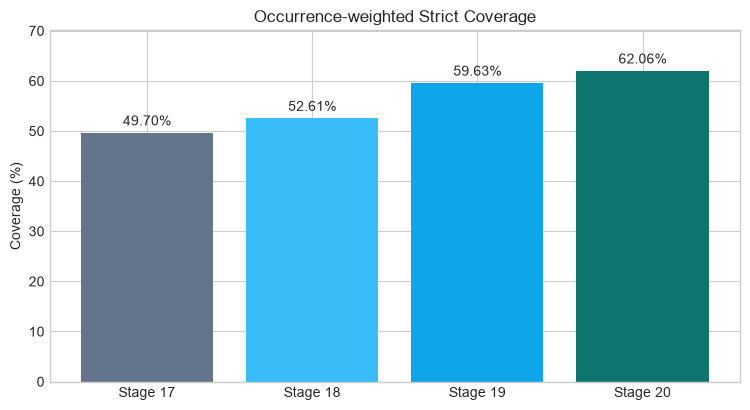

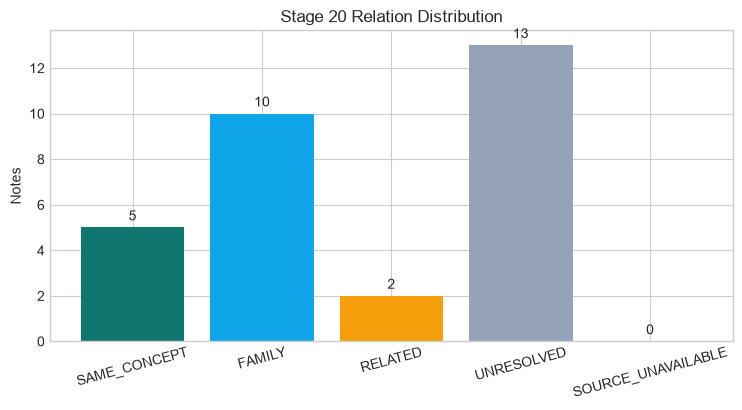

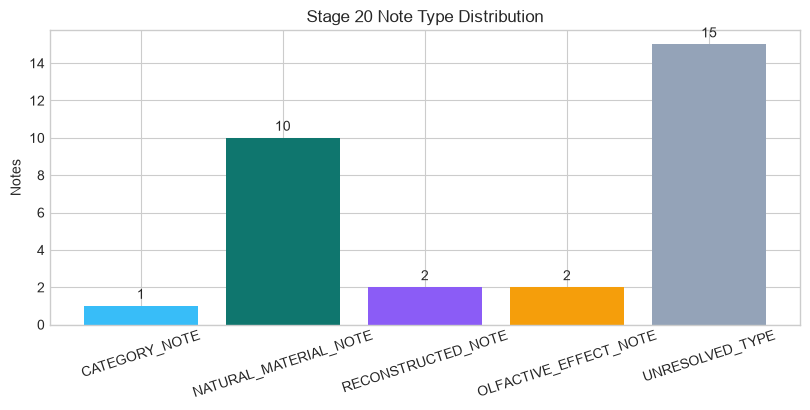

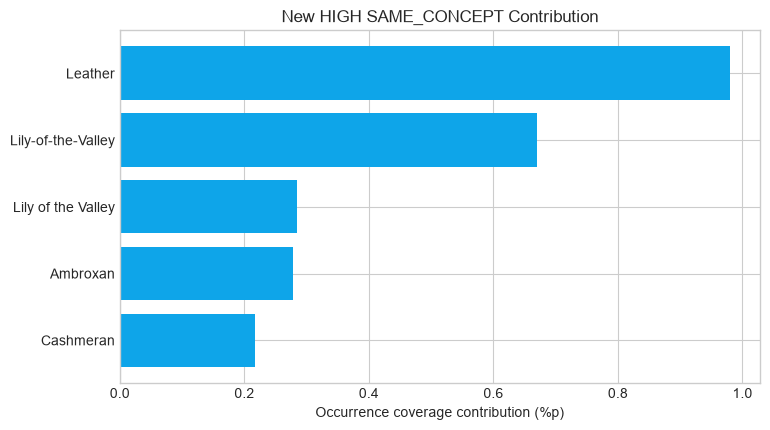

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(7.6, 4.2))
bars = ax.bar(stage_metrics["stage"], stage_metrics["occurrence_weighted_coverage"] * 100,
              color=["#64748B", "#38BDF8", "#0EA5E9", "#0F766E"])
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.set_title("Occurrence-weighted Strict Coverage")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, max(stage_metrics["occurrence_weighted_coverage"] * 100) + 8)
plt.tight_layout(); plt.show()

relation_order = ["SAME_CONCEPT", "FAMILY", "RELATED", "UNRESOLVED", "SOURCE_UNAVAILABLE"]
relation_counts = decisions["relation_type"].value_counts().reindex(relation_order, fill_value=0)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
bars = ax.bar(relation_counts.index, relation_counts.values,
              color=["#0F766E", "#0EA5E9", "#F59E0B", "#94A3B8", "#DC2626"])
ax.bar_label(bars, padding=3)
ax.set_title("Stage 20 Relation Distribution")
ax.set_ylabel("Notes")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

type_order = ["CATEGORY_NOTE", "NATURAL_MATERIAL_NOTE", "RECONSTRUCTED_NOTE", "OLFACTIVE_EFFECT_NOTE", "UNRESOLVED_TYPE"]
type_counts = decisions["note_type"].value_counts().reindex(type_order, fill_value=0)
fig, ax = plt.subplots(figsize=(8.2, 4.2))
bars = ax.bar(type_counts.index, type_counts.values,
              color=["#38BDF8", "#0F766E", "#8B5CF6", "#F59E0B", "#94A3B8"])
ax.bar_label(bars, padding=3)
ax.set_title("Stage 20 Note Type Distribution")
ax.set_ylabel("Notes")
plt.xticks(rotation=18); plt.tight_layout(); plt.show()

plot_contribution = contribution.sort_values("coverage_contribution_percentage_point")
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.barh(plot_contribution["term"], plot_contribution["coverage_contribution_percentage_point"], color="#0EA5E9")
ax.set_title("New HIGH SAME_CONCEPT Contribution")
ax.set_xlabel("Occurrence coverage contribution (%p)")
plt.tight_layout(); plt.show()



## 7. 요약과 Semantic Bridge 판단


In [8]:
m19 = stage_metrics.set_index("stage").loc["Stage 19"]
m20 = stage_metrics.set_index("stage").loc["Stage 20"]
delta_occ_pp = (m20["occurrence_weighted_coverage"] - m19["occurrence_weighted_coverage"]) * 100
delta_perfume_pp = (m20["perfume_level_coverage"] - m19["perfume_level_coverage"]) * 100
top100 = top_comparison.set_index("top_n").loc[100]
top200 = top_comparison.set_index("top_n").loc[200]
relation_counts = decisions["relation_type"].value_counts()
type_counts = decisions["note_type"].value_counts()

source_best = source_effect.sort_values(
    ["same_concept_count", "family_count", "related_count", "supported_term_count"], ascending=False
).iloc[0]["source_group"]

recommendation = (
    "추가 일반 소스를 넓게 수집하기보다 Semantic Bridge Pilot으로 이동한다. "
    "Stage 20은 Leather, 두 Lily-of-the-Valley 표기, Ambroxan, Cashmeran을 strict mapping으로 확정했고, "
    "Mandarin Orange·Orange Blossom·Pink/Black Pepper·Mint·지역 Rose·Orris·Bitter Orange는 "
    "과대 동일시 없이 FAMILY 구조로 확보했다. 남은 Freesia, Woodsy Notes, Orchid, Cashmere Wood 등은 "
    "단순 자료 누락만이 아니라 재구성 향·카테고리·마케팅형 Note 경계 문제이므로, FAMILY/RELATED를 "
    "특징으로 활용하는 Pilot이 다음 검증에 더 직접적이다. 다만 남은 고빈도 Gap은 별도 수동 검토 백로그로 유지한다."
)

metric_display = stage_metrics.copy()
for column in ["vocabulary_coverage", "occurrence_weighted_coverage", "perfume_level_coverage"]:
    metric_display[column] = metric_display[column].map(lambda value: f"{value:.2%}")

relation_table = pd.DataFrame({
    "relation_type": relation_order,
    "count": [int(relation_counts.get(name, 0)) for name in relation_order],
})
type_table = pd.DataFrame({
    "note_type": type_order,
    "count": [int(type_counts.get(name, 0)) for name in type_order],
})

summary = f"""# External Scent Knowledge Validation

## 결과 요약

### 결론

- 검증 Note 수: **{len(decisions):,}**
- 신규 SAME_CONCEPT: **{relation_counts.get('SAME_CONCEPT', 0):,}**
- FAMILY: **{relation_counts.get('FAMILY', 0):,}**
- RELATED: **{relation_counts.get('RELATED', 0):,}**
- UNRESOLVED: **{relation_counts.get('UNRESOLVED', 0):,}**
- SOURCE_UNAVAILABLE: **{relation_counts.get('SOURCE_UNAVAILABLE', 0):,}**
- Stage 19 → 20 occurrence-weighted coverage: **{m19['occurrence_weighted_coverage']:.2%} → {m20['occurrence_weighted_coverage']:.2%} ({delta_occ_pp:+.2f}%p)**
- 외부 공식 Source는 strict mapping 5개와 material/category 관계 12개를 보강해 실제로 도움이 됐다. 특히 IFF가 가장 넓은 범위를 지원했고, dsm-firmenich와 PubChem은 각각 Muguet와 Ambroxan의 결정적 명칭 근거를 제공했다.

## 핵심 수치

{markdown_table(metric_display)}

## 상세

### 1. 분석 목적

Stage 19에서 IFRA만으로 해결하지 못한 고빈도 Note를 허용된 공식 업계 자료로 검증하고, strict mapping과 비동일 관계를 분리해 향 지식 DB의 핵심 빈틈을 보완했다. Semantic Bridge나 embedding은 구현하지 않았다.

### 2. 검증 대상 선정 기준

`19_high_frequency_unresolved_notes.csv`에서 Stage 19 relation이 RELATED 또는 UNRESOLVED인 항목을 occurrence_count 내림차순으로 정렬해 상위 30개를 선택했다. 요청된 대표 10개는 모두 실제 상위 30개에 포함됐다.

### 3. 추가한 공식 Source

- IFRA 로컬 PDF/처리 CSV: Mint material family와 기존 descriptor 관계 재확인
- Givaudan 공식 Natural Ingredients: Neroli/Orange Blossom의 material 차이, Virginia cedarwood 확인
- IFF Fragrance Ingredients 및 LMR Compendium: Leather category, Cashmeran, natural material 및 marine/mossy 관계 확인
- dsm-firmenich Perfumery & Beauty Ingredients: Muguet–Lily-of-the-Valley 직접 명칭 관계와 Pink Pepper extract 확인
- PubChem: Ambroxan–Ambroxide chemical synonym만 확인
- 검색 snippet, 비공식 사이트, 브랜드 마케팅 설명은 Evidence로 저장하지 않았다.

### 4. Note Type 분석

{markdown_table(type_table)}

Natural material 계열이 10개였지만 특정 oil/extract와 Note를 동일시할 수 없어 FAMILY가 됐다. 15개는 공식 근거 부족 또는 허용 taxonomy에 synthetic-ingredient type이 없어 UNRESOLVED_TYPE으로 남았다.

### 5. Relation 판정 결과

{markdown_table(relation_table)}

### 6. 신규 SAME_CONCEPT

{markdown_table(decisions.loc[decisions['relation_type'].eq('SAME_CONCEPT'), ['note', 'candidate_term', 'note_type', 'confidence', 'evidence_sources']])}

이 5개만 Stage 20 strict coverage에 추가했다. FAMILY/RELATED는 제외했다.

### 7. 주요 FAMILY / RELATED 관계

{markdown_table(decisions.loc[decisions['relation_type'].isin(['FAMILY', 'RELATED']), ['note', 'candidate_term', 'parent_term', 'relation_type', 'note_type']])}

Orange Blossom과 Neroli는 extraction/material 차이가 공식적으로 확인돼 SAME_CONCEPT로 합치지 않았다. Mint/Peppermint/Spearmint, Moss/Oakmoss, natural note/oil 관계도 동일한 보수 원칙을 적용했다.

### 8. Coverage 변화

- Strict matched Note: **{int(m19['strict_matched_note_count'])} → {int(m20['strict_matched_note_count'])}**
- Vocabulary coverage: **{m19['vocabulary_coverage']:.2%} → {m20['vocabulary_coverage']:.2%}**
- Occurrence-weighted coverage: **{m19['occurrence_weighted_coverage']:.2%} → {m20['occurrence_weighted_coverage']:.2%}**
- Perfume-level coverage: **{m19['perfume_level_coverage']:.2%} → {m20['perfume_level_coverage']:.2%} ({delta_perfume_pp:+.2f}%p)**
- Top 100 vocabulary coverage: **{top100['stage19_vocabulary_coverage']:.2%} → {top100['stage20_vocabulary_coverage']:.2%}**
- Top 200 vocabulary coverage: **{top200['stage19_vocabulary_coverage']:.2%} → {top200['stage20_vocabulary_coverage']:.2%}**

### 9. Coverage 기여도가 높은 Mapping

{markdown_table(contribution)}

### 10. Source별 활용도

{markdown_table(source_effect)}

`{source_best}`가 final relation을 지원한 범위가 가장 넓었다. dsm-firmenich는 두 Lily 표기의 SAME_CONCEPT를, PubChem은 Ambroxan의 화학 동의어를 좁고 결정적으로 확인했다. Multiple Sources는 같은 term에 둘 이상의 공식 기관 근거가 있는 경우다.

### 11. 아직 남은 고빈도 Gap

{markdown_table(remaining.head(13)[['note', 'perfume_count', 'occurrence_count', 'relation_type', 'note_type']])}

### 12. IFRA만으로 해결되지 않았던 이유

- Fragrantica Note가 특정 ingredient가 아니라 넓은 natural-material family인 경우가 많았다.
- Leather, Sea Notes, Moss처럼 olfactive category/effect와 ingredient identity가 다른 항목이 있었다.
- Lily-of-the-Valley처럼 공식 업계의 reconstructed terminology가 IFRA principal-name strict match와 다른 층위에 있었다.
- Ambroxan/Cashmeran처럼 synthetic ingredient name은 이번 Note Type 선택지에 별도 유형이 없었다.

### 13. 이번 분석에서 검증된 것

- 실제 공식 페이지를 근거로 5개 HIGH SAME_CONCEPT를 strict mapping에 추가할 수 있다.
- 10개 natural-material Note는 특정 원료와 동일시하지 않고 FAMILY로 구조화할 수 있다.
- Orange Blossom/Neroli 및 broad note/specific extract를 분리해야 coverage가 과대평가되지 않는다.

### 14. 아직 검증되지 않은 것

- Freesia, Orchid, Lotus 등 꽃 Note의 natural/reconstructed 경계
- Cashmere Wood, Amberwood, Suede 등 상업적·효과 중심 표현의 공식 taxonomy
- Vanille의 공식 alternative naming과 Fig의 fruit/leaf/material 구분
- 추천 Query를 descriptor로 변환하는 Semantic Bridge 성능

### 15. Semantic Bridge 진행 여부 판단

**{recommendation}**

이 판단은 임의 coverage threshold가 아니라 occurrence-weighted 및 Top 100/200 변화, 해결된 고빈도 Note, FAMILY/RELATED로 확보된 구조, 남은 gap의 성격을 함께 고려했다.

### 16. 다음 단계

1. Stage 20의 HIGH SAME_CONCEPT 5개만 strict lookup에 반영한다.
2. FAMILY/RELATED는 정답 label이 아닌 Semantic Bridge feature로 사용하는 Pilot을 설계한다.
3. Freesia, Woodsy Notes, Orchid, Cashmere Wood를 우선 수동 검토 백로그로 유지한다.
4. synthetic ingredient를 명시할 별도 Note Type 추가 여부를 다음 dictionary schema revision에서 검토한다.
"""

(OUTPUT / "20_external_scent_knowledge_validation_summary.md").write_text(summary, encoding="utf-8")
display(Markdown(summary))



# External Scent Knowledge Validation

## 결과 요약

### 결론

- 검증 Note 수: **30**
- 신규 SAME_CONCEPT: **5**
- FAMILY: **10**
- RELATED: **2**
- UNRESOLVED: **13**
- SOURCE_UNAVAILABLE: **0**
- Stage 19 → 20 occurrence-weighted coverage: **59.63% → 62.06% (+2.43%p)**
- 외부 공식 Source는 strict mapping 5개와 material/category 관계 12개를 보강해 실제로 도움이 됐다. 특히 IFF가 가장 넓은 범위를 지원했고, dsm-firmenich와 PubChem은 각각 Muguet와 Ambroxan의 결정적 명칭 근거를 제공했다.

## 핵심 수치

| stage | strict_matched_note_count | vocabulary_coverage | occurrence_weighted_coverage | perfume_level_coverage | matched_occurrence_count | total_note_types | total_occurrence_count | total_perfumes |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Stage 17 | 159 | 6.30% | 49.70% | 92.31% | 545863 | 2523 | 1098223 | 131930 |
| Stage 18 | 165 | 6.54% | 52.61% | 94.27% | 577745 | 2523 | 1098223 | 131930 |
| Stage 19 | 180 | 7.13% | 59.63% | 95.57% | 654910 | 2523 | 1098223 | 131930 |
| Stage 20 | 185 | 7.33% | 62.06% | 95.82% | 681598 | 2523 | 1098223 | 131930 |

## 상세

### 1. 분석 목적

Stage 19에서 IFRA만으로 해결하지 못한 고빈도 Note를 허용된 공식 업계 자료로 검증하고, strict mapping과 비동일 관계를 분리해 향 지식 DB의 핵심 빈틈을 보완했다. Semantic Bridge나 embedding은 구현하지 않았다.

### 2. 검증 대상 선정 기준

`19_high_frequency_unresolved_notes.csv`에서 Stage 19 relation이 RELATED 또는 UNRESOLVED인 항목을 occurrence_count 내림차순으로 정렬해 상위 30개를 선택했다. 요청된 대표 10개는 모두 실제 상위 30개에 포함됐다.

### 3. 추가한 공식 Source

- IFRA 로컬 PDF/처리 CSV: Mint material family와 기존 descriptor 관계 재확인
- Givaudan 공식 Natural Ingredients: Neroli/Orange Blossom의 material 차이, Virginia cedarwood 확인
- IFF Fragrance Ingredients 및 LMR Compendium: Leather category, Cashmeran, natural material 및 marine/mossy 관계 확인
- dsm-firmenich Perfumery & Beauty Ingredients: Muguet–Lily-of-the-Valley 직접 명칭 관계와 Pink Pepper extract 확인
- PubChem: Ambroxan–Ambroxide chemical synonym만 확인
- 검색 snippet, 비공식 사이트, 브랜드 마케팅 설명은 Evidence로 저장하지 않았다.

### 4. Note Type 분석

| note_type | count |
| --- | --- |
| CATEGORY_NOTE | 1 |
| NATURAL_MATERIAL_NOTE | 10 |
| RECONSTRUCTED_NOTE | 2 |
| OLFACTIVE_EFFECT_NOTE | 2 |
| UNRESOLVED_TYPE | 15 |

Natural material 계열이 10개였지만 특정 oil/extract와 Note를 동일시할 수 없어 FAMILY가 됐다. 15개는 공식 근거 부족 또는 허용 taxonomy에 synthetic-ingredient type이 없어 UNRESOLVED_TYPE으로 남았다.

### 5. Relation 판정 결과

| relation_type | count |
| --- | --- |
| SAME_CONCEPT | 5 |
| FAMILY | 10 |
| RELATED | 2 |
| UNRESOLVED | 13 |
| SOURCE_UNAVAILABLE | 0 |

### 6. 신규 SAME_CONCEPT

| note | candidate_term | note_type | confidence | evidence_sources |
| --- | --- | --- | --- | --- |
| Leather | Leather | OLFACTIVE_EFFECT_NOTE | HIGH | IFF |
| Lily-of-the-Valley | Muguet | RECONSTRUCTED_NOTE | HIGH | dsm-firmenich |
| Lily of the Valley | Muguet | RECONSTRUCTED_NOTE | HIGH | dsm-firmenich |
| Ambroxan | Ambroxide | UNRESOLVED_TYPE | HIGH | PubChem |
| Cashmeran | Cashmeran | UNRESOLVED_TYPE | HIGH | IFF |

이 5개만 Stage 20 strict coverage에 추가했다. FAMILY/RELATED는 제외했다.

### 7. 주요 FAMILY / RELATED 관계

| note | candidate_term | parent_term | relation_type | note_type |
| --- | --- | --- | --- | --- |
| Mandarin Orange | Mandarin Oil Green Italy | Mandarin material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Orange Blossom | Orange Flower Absolute \| Neroli Oil | Bitter orange flower material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Pink Pepper | Pink Pepper CO2 | Pink pepper material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Black Pepper | Black Pepper Oil Madagascar | Black pepper material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Mint | Mentha material forms | Mint material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Moss | Mossy | Mossy | RELATED | OLFACTIVE_EFFECT_NOTE |
| Virginia Cedar | Cedarwood Virginia Oil USA | Virginia cedarwood material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Sea Notes | Marine | Marine | RELATED | CATEGORY_NOTE |
| Orris Root | Orris Natural | Orris rhizome material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Bulgarian Rose | Rose Oil Bulgaria | Bulgarian Rosa damascena material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Turkish Rose | Rose Oil Isparta | Turkish Rosa damascena material family | FAMILY | NATURAL_MATERIAL_NOTE |
| Bitter Orange | Orange Oil CP Bitter Egypt | Bitter orange material family | FAMILY | NATURAL_MATERIAL_NOTE |

Orange Blossom과 Neroli는 extraction/material 차이가 공식적으로 확인돼 SAME_CONCEPT로 합치지 않았다. Mint/Peppermint/Spearmint, Moss/Oakmoss, natural note/oil 관계도 동일한 보수 원칙을 적용했다.

### 8. Coverage 변화

- Strict matched Note: **180 → 185**
- Vocabulary coverage: **7.13% → 7.33%**
- Occurrence-weighted coverage: **59.63% → 62.06%**
- Perfume-level coverage: **95.57% → 95.82% (+0.25%p)**
- Top 100 vocabulary coverage: **68.00% → 73.00%**
- Top 200 vocabulary coverage: **53.50% → 56.00%**

### 9. Coverage 기여도가 높은 Mapping

| term | canonical_term | occurrence_count | coverage_contribution_percentage_point | cumulative_contribution |
| --- | --- | --- | --- | --- |
| Leather | Leather | 10754 | 0.9792182462031847 | 0.9792182462031847 |
| Lily-of-the-Valley | Muguet | 7366 | 0.6707198811170408 | 1.6499381273202256 |
| Lily of the Valley | Muguet | 3118 | 0.2839131943148159 | 1.9338513216350415 |
| Ambroxan | Ambroxide | 3062 | 0.2788140477844664 | 2.2126653694195078 |
| Cashmeran | Cashmeran | 2388 | 0.21744217704418867 | 2.4301075464636965 |

### 10. Source별 활용도

| source_group | evidence_count | supported_term_count | same_concept_count | family_count | related_count |
| --- | --- | --- | --- | --- | --- |
| IFRA | 16 | 16 | 0 | 1 | 2 |
| Givaudan | 2 | 2 | 0 | 2 | 0 |
| IFF | 25 | 25 | 2 | 8 | 2 |
| dsm-firmenich | 3 | 3 | 2 | 1 | 0 |
| PubChem | 1 | 1 | 1 | 0 | 0 |
| Multiple Sources | 34 | 17 | 0 | 2 | 2 |

`IFF`가 final relation을 지원한 범위가 가장 넓었다. dsm-firmenich는 두 Lily 표기의 SAME_CONCEPT를, PubChem은 Ambroxan의 화학 동의어를 좁고 결정적으로 확인했다. Multiple Sources는 같은 term에 둘 이상의 공식 기관 근거가 있는 경우다.

### 11. 아직 남은 고빈도 Gap

| note | perfume_count | occurrence_count | relation_type | note_type |
| --- | --- | --- | --- | --- |
| Freesia | 5683 | 5696 | UNRESOLVED | UNRESOLVED_TYPE |
| Moss | 4302 | 4310 | RELATED | OLFACTIVE_EFFECT_NOTE |
| Woodsy Notes | 3240 | 3250 | UNRESOLVED | UNRESOLVED_TYPE |
| Orchid | 2814 | 2824 | UNRESOLVED | UNRESOLVED_TYPE |
| Cashmere Wood | 2688 | 2691 | UNRESOLVED | UNRESOLVED_TYPE |
| White Flowers | 2317 | 2323 | UNRESOLVED | UNRESOLVED_TYPE |
| Sea Notes | 2183 | 2193 | RELATED | CATEGORY_NOTE |
| Praline | 2164 | 2171 | UNRESOLVED | UNRESOLVED_TYPE |
| Sugar | 2094 | 2116 | UNRESOLVED | UNRESOLVED_TYPE |
| Vanille | 2033 | 2037 | UNRESOLVED | UNRESOLVED_TYPE |
| Fig | 1810 | 1846 | UNRESOLVED | UNRESOLVED_TYPE |
| Lotus | 1771 | 1781 | UNRESOLVED | UNRESOLVED_TYPE |
| Amberwood | 1757 | 1761 | UNRESOLVED | UNRESOLVED_TYPE |

### 12. IFRA만으로 해결되지 않았던 이유

- Fragrantica Note가 특정 ingredient가 아니라 넓은 natural-material family인 경우가 많았다.
- Leather, Sea Notes, Moss처럼 olfactive category/effect와 ingredient identity가 다른 항목이 있었다.
- Lily-of-the-Valley처럼 공식 업계의 reconstructed terminology가 IFRA principal-name strict match와 다른 층위에 있었다.
- Ambroxan/Cashmeran처럼 synthetic ingredient name은 이번 Note Type 선택지에 별도 유형이 없었다.

### 13. 이번 분석에서 검증된 것

- 실제 공식 페이지를 근거로 5개 HIGH SAME_CONCEPT를 strict mapping에 추가할 수 있다.
- 10개 natural-material Note는 특정 원료와 동일시하지 않고 FAMILY로 구조화할 수 있다.
- Orange Blossom/Neroli 및 broad note/specific extract를 분리해야 coverage가 과대평가되지 않는다.

### 14. 아직 검증되지 않은 것

- Freesia, Orchid, Lotus 등 꽃 Note의 natural/reconstructed 경계
- Cashmere Wood, Amberwood, Suede 등 상업적·효과 중심 표현의 공식 taxonomy
- Vanille의 공식 alternative naming과 Fig의 fruit/leaf/material 구분
- 추천 Query를 descriptor로 변환하는 Semantic Bridge 성능

### 15. Semantic Bridge 진행 여부 판단

**추가 일반 소스를 넓게 수집하기보다 Semantic Bridge Pilot으로 이동한다. Stage 20은 Leather, 두 Lily-of-the-Valley 표기, Ambroxan, Cashmeran을 strict mapping으로 확정했고, Mandarin Orange·Orange Blossom·Pink/Black Pepper·Mint·지역 Rose·Orris·Bitter Orange는 과대 동일시 없이 FAMILY 구조로 확보했다. 남은 Freesia, Woodsy Notes, Orchid, Cashmere Wood 등은 단순 자료 누락만이 아니라 재구성 향·카테고리·마케팅형 Note 경계 문제이므로, FAMILY/RELATED를 특징으로 활용하는 Pilot이 다음 검증에 더 직접적이다. 다만 남은 고빈도 Gap은 별도 수동 검토 백로그로 유지한다.**

이 판단은 임의 coverage threshold가 아니라 occurrence-weighted 및 Top 100/200 변화, 해결된 고빈도 Note, FAMILY/RELATED로 확보된 구조, 남은 gap의 성격을 함께 고려했다.

### 16. 다음 단계

1. Stage 20의 HIGH SAME_CONCEPT 5개만 strict lookup에 반영한다.
2. FAMILY/RELATED는 정답 label이 아닌 Semantic Bridge feature로 사용하는 Pilot을 설계한다.
3. Freesia, Woodsy Notes, Orchid, Cashmere Wood를 우선 수동 검토 백로그로 유지한다.
4. synthetic ingredient를 명시할 별도 Note Type 추가 여부를 다음 dictionary schema revision에서 검토한다.


## 8. 종료 검증


In [9]:
expected_outputs = [
    ROOT / "20_external_scent_knowledge_validation.ipynb",
    KNOWLEDGE / "scent_term_dictionary_v0.3.csv",
    KNOWLEDGE / "scent_term_evidence_v0.3.csv",
    OUTPUT / "20_external_validation_targets.csv",
    OUTPUT / "20_external_note_validation_decisions.csv",
    OUTPUT / "20_top_note_coverage_comparison.csv",
    OUTPUT / "20_mapping_coverage_contribution.csv",
    OUTPUT / "20_remaining_high_frequency_gaps.csv",
    OUTPUT / "20_external_scent_knowledge_validation_summary.md",
]

assert len(targets) == 30
assert set(decisions["note"]) == set(targets["note"])
assert set(decisions["note_type"]).issubset({
    "CATEGORY_NOTE", "NATURAL_MATERIAL_NOTE", "RECONSTRUCTED_NOTE",
    "OLFACTIVE_EFFECT_NOTE", "UNRESOLVED_TYPE",
})
assert set(decisions["relation_type"]).issubset({
    "SAME_CONCEPT", "FAMILY", "RELATED", "UNRESOLVED", "SOURCE_UNAVAILABLE",
})
assert len(stage20_added) == 5
assert len(contribution) == len(stage20_added)
assert not decisions.loc[
    decisions["relation_type"].isin(["FAMILY", "RELATED", "UNRESOLVED", "SOURCE_UNAVAILABLE"]), "note"
].isin(stage20_added).any()
assert len(remaining) == int(decisions["relation_type"].isin(["RELATED", "UNRESOLVED", "SOURCE_UNAVAILABLE"]).sum())
assert all(path.exists() for path in expected_outputs)

print("Validation passed.")
print(f"Targets={len(targets)}, SAME={relation_counts.get('SAME_CONCEPT', 0)}, "
      f"FAMILY={relation_counts.get('FAMILY', 0)}, RELATED={relation_counts.get('RELATED', 0)}, "
      f"UNRESOLVED={relation_counts.get('UNRESOLVED', 0)}, "
      f"SOURCE_UNAVAILABLE={relation_counts.get('SOURCE_UNAVAILABLE', 0)}")
print(f"Stage 19 -> 20 occurrence coverage: {m19['occurrence_weighted_coverage']:.4%} -> {m20['occurrence_weighted_coverage']:.4%}")
print(f"Stage 19 -> 20 perfume coverage: {m19['perfume_level_coverage']:.4%} -> {m20['perfume_level_coverage']:.4%}")
print("Recommendation:", recommendation)
print("Artifacts:")
for path in expected_outputs:
    print("-", path.relative_to(ROOT))


Validation passed.
Targets=30, SAME=5, FAMILY=10, RELATED=2, UNRESOLVED=13, SOURCE_UNAVAILABLE=0
Stage 19 -> 20 occurrence coverage: 59.6336% -> 62.0637%
Stage 19 -> 20 perfume coverage: 95.5749% -> 95.8228%
Recommendation: 추가 일반 소스를 넓게 수집하기보다 Semantic Bridge Pilot으로 이동한다. Stage 20은 Leather, 두 Lily-of-the-Valley 표기, Ambroxan, Cashmeran을 strict mapping으로 확정했고, Mandarin Orange·Orange Blossom·Pink/Black Pepper·Mint·지역 Rose·Orris·Bitter Orange는 과대 동일시 없이 FAMILY 구조로 확보했다. 남은 Freesia, Woodsy Notes, Orchid, Cashmere Wood 등은 단순 자료 누락만이 아니라 재구성 향·카테고리·마케팅형 Note 경계 문제이므로, FAMILY/RELATED를 특징으로 활용하는 Pilot이 다음 검증에 더 직접적이다. 다만 남은 고빈도 Gap은 별도 수동 검토 백로그로 유지한다.
Artifacts:
- 20_external_scent_knowledge_validation.ipynb
- data\scent_knowledge\scent_term_dictionary_v0.3.csv
- data\scent_knowledge\scent_term_evidence_v0.3.csv
- analysis_outputs\20_external_validation_targets.csv
- analysis_outputs\20_external_note_validation_decisions.csv
- analysis_outputs\20_top_note_coverage_comparison.csv
- analysis_ou